<a href="https://colab.research.google.com/github/ligimathew123/Retail-Demand-Forecasting-Inventory-Optimization/blob/main/notebooks/retail_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import zipfile

with zipfile.ZipFile("sales_train_evaluation.csv.zip", "r") as zip_ref:
    zip_ref.extractall(".")

with zipfile.ZipFile("sell_prices.csv.zip", "r") as zip_ref:
    zip_ref.extractall(".")

In [ ]:
sales = pd.read_csv("sales_train_evaluation.csv")
prices = pd.read_csv("sell_prices.csv")
calendar = pd.read_excel("calendarfile.xlsx")

print("Sales shape:", sales.shape)
print("Prices shape:", prices.shape)
print("Calendar shape:", calendar.shape)

Sales shape: (30490, 1947)
Prices shape: (6841121, 4)
Calendar shape: (1969, 14)


In [ ]:
print("Sales:")
display(sales.head())
print(sales.info())

print("\nPrices:")
display(prices.head())
print(prices.info())

print("\nCalendar:")
display(calendar.head())
print(calendar.info())

Sales:


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), object(6)
memory usage: 452.9+ MB
None

Prices:


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    object 
 1   item_id     object 
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 208.8+ MB
None

Calendar:


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1969 non-null   datetime64[ns]
 1   wm_yr_wk      1969 non-null   int64         
 2   weekday       1969 non-null   object        
 3   wday          1969 non-null   int64         
 4   month         1969 non-null   int64         
 5   year          1969 non-null   int64         
 6   d             1969 non-null   object        
 7   event_name_1  162 non-null    object        
 8   event_type_1  162 non-null    object        
 9   event_name_2  5 non-null      object        
 10  event_type_2  5 non-null      object        
 11  snap_CA       1969 non-null   int64         
 12  snap_TX       1969 non-null   int64         
 13  snap_WI       1969 non-null   int64         
dtypes: datetime64[ns](1), int64(7), object(6)
memory usage: 215.5+ KB
None


In [ ]:
print("Sales missing values:", sales.isnull().sum().sum())
print("Prices missing values:", prices.isnull().sum().sum())
print("Calendar missing values:", calendar.isnull().sum().sum())

Sales missing values: 0
Prices missing values: 0
Calendar missing values: 7542


In [ ]:
calendar.isnull().sum()

,0
date,0
wm_yr_wk,0
weekday,0
wday,0
month,0
year,0
d,0
event_name_1,1807
event_type_1,1807
event_name_2,1964


In [ ]:
print(calendar.columns.tolist())

['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']


In [ ]:
display(calendar.head(10))

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
5,2011-02-03,11101,Thursday,6,2,2011,d_6,NaN,NaN,NaN,NaN,1,1,1
6,2011-02-04,11101,Friday,7,2,2011,d_7,NaN,NaN,NaN,NaN,1,0,0
7,2011-02-05,11102,Saturday,1,2,2011,d_8,NaN,NaN,NaN,NaN,1,1,1
8,2011-02-06,11102,Sunday,2,2,2011,d_9,SuperBowl,Sporting,NaN,NaN,1,1,1
9,2011-02-07,11102,Monday,3,2,2011,d_10,NaN,NaN,NaN,NaN,1,1,0


In [ ]:
event_columns = [
    'event_name_1',
    'event_type_1',
    'event_name_2',
    'event_type_2'
]

calendar[event_columns] = calendar[event_columns].fillna('None')

In [ ]:
calendar[event_columns].isnull().sum()

,0
event_name_1,0
event_type_1,0
event_name_2,0
event_type_2,0


In [ ]:
calendar.dtypes

,0
date,datetime64[ns]
wm_yr_wk,int64
weekday,object
wday,int64
month,int64
year,int64
d,object
event_name_1,object
event_type_1,object
event_name_2,object


In [ ]:
prices.dtypes

,0
store_id,object
item_id,object
wm_yr_wk,int64
sell_price,float64


In [ ]:
sales.dtypes

,0
id,object
item_id,object
dept_id,object
cat_id,object
store_id,object
...,...
d_1937,int64
d_1938,int64
d_1939,int64
d_1940,int64


In [ ]:
display(sales.head())

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [ ]:
display(
    sales[['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']].head()
)

,id,item_id,dept_id,cat_id,store_id,state_id
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA


EDA

In [ ]:
print("Unique items:", sales['item_id'].nunique())
print("Unique departments:", sales['dept_id'].nunique())
print("Unique categories:", sales['cat_id'].nunique())
print("Unique stores:", sales['store_id'].nunique())
print("Unique states:", sales['state_id'].nunique())

Unique items: 3049
Unique departments: 7
Unique categories: 3
Unique stores: 10
Unique states: 3


In [ ]:
print("Categories:")
print(sales['cat_id'].unique())

print("\nDepartments:")
print(sales['dept_id'].unique())

print("\nStores:")
print(sales['store_id'].unique())

print("\nStates:")
print(sales['state_id'].unique())

Categories:
['HOBBIES' 'HOUSEHOLD' 'FOODS']

Departments:
['HOBBIES_1' 'HOBBIES_2' 'HOUSEHOLD_1' 'HOUSEHOLD_2' 'FOODS_1' 'FOODS_2'
 'FOODS_3']

Stores:
['CA_1' 'CA_2' 'CA_3' 'CA_4' 'TX_1' 'TX_2' 'TX_3' 'WI_1' 'WI_2' 'WI_3']

States:
['CA' 'TX' 'WI']


In [ ]:
sales_columns = [col for col in sales.columns if col.startswith('d_')]

print("Number of daily sales columns:", len(sales_columns))

Number of daily sales columns: 1941


In [ ]:
total_sales = sales[sales_columns].sum().sum()

print("Total sales:", total_sales)

Total sales: 66927173


In [ ]:
sales['total_sales'] = sales[sales_columns].sum(axis=1)

top_items = (
    sales[['id', 'item_id', 'dept_id', 'cat_id',
           'store_id', 'state_id', 'total_sales']]
    .sort_values('total_sales', ascending=False)
    .head(10)
)

display(top_items)

,id,item_id,dept_id,cat_id,store_id,state_id,total_sales
8412,FOODS_3_090_CA_3_evaluation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,253859
18055,FOODS_3_586_TX_2_evaluation,FOODS_3_586,FOODS_3,FOODS,TX_2,TX,195120
21104,FOODS_3_586_TX_3_evaluation,FOODS_3_586,FOODS_3,FOODS,TX_3,TX,151862
8908,FOODS_3_586_CA_3_evaluation,FOODS_3_586,FOODS_3,FOODS,CA_3,CA,136269
2314,FOODS_3_090_CA_1_evaluation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,128855
29755,FOODS_3_090_WI_3_evaluation,FOODS_3_090,FOODS_3,FOODS,WI_3,WI,123500
17559,FOODS_3_090_TX_2_evaluation,FOODS_3_090,FOODS_3,FOODS,TX_2,TX,121275
20608,FOODS_3_090_TX_3_evaluation,FOODS_3_090,FOODS_3,FOODS,TX_3,TX,116773
17721,FOODS_3_252_TX_2_evaluation,FOODS_3_252,FOODS_3,FOODS,TX_2,TX,115613
15006,FOODS_3_586_TX_1_evaluation,FOODS_3_586,FOODS_3,FOODS,TX_1,TX,114010


In [ ]:
print("Categories:")
print(sales['cat_id'].unique())

print("\nDepartments:")
print(sales['dept_id'].unique())

print("\nStores:")
print(sales['store_id'].unique())

print("\nStates:")
print(sales['state_id'].unique())

Categories:
['HOBBIES' 'HOUSEHOLD' 'FOODS']

Departments:
['HOBBIES_1' 'HOBBIES_2' 'HOUSEHOLD_1' 'HOUSEHOLD_2' 'FOODS_1' 'FOODS_2'
 'FOODS_3']

Stores:
['CA_1' 'CA_2' 'CA_3' 'CA_4' 'TX_1' 'TX_2' 'TX_3' 'WI_1' 'WI_2' 'WI_3']

States:
['CA' 'TX' 'WI']


In [ ]:
sales_columns = [col for col in sales.columns if col.startswith('d_')]

print("Number of daily sales columns:", len(sales_columns))

total_sales = sales[sales_columns].sum().sum()

print("Total sales:", total_sales)

Number of daily sales columns: 1941
Total sales: 66927173


In [ ]:
#Find the top 10 selling products
sales['total_sales'] = sales[sales_columns].sum(axis=1)

top_items = (
    sales[['id', 'item_id', 'dept_id', 'cat_id',
           'store_id', 'state_id', 'total_sales']]
    .sort_values('total_sales', ascending=False)
    .head(10)
)

display(top_items)

,id,item_id,dept_id,cat_id,store_id,state_id,total_sales
8412,FOODS_3_090_CA_3_evaluation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,253859
18055,FOODS_3_586_TX_2_evaluation,FOODS_3_586,FOODS_3,FOODS,TX_2,TX,195120
21104,FOODS_3_586_TX_3_evaluation,FOODS_3_586,FOODS_3,FOODS,TX_3,TX,151862
8908,FOODS_3_586_CA_3_evaluation,FOODS_3_586,FOODS_3,FOODS,CA_3,CA,136269
2314,FOODS_3_090_CA_1_evaluation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,128855
29755,FOODS_3_090_WI_3_evaluation,FOODS_3_090,FOODS_3,FOODS,WI_3,WI,123500
17559,FOODS_3_090_TX_2_evaluation,FOODS_3_090,FOODS_3,FOODS,TX_2,TX,121275
20608,FOODS_3_090_TX_3_evaluation,FOODS_3_090,FOODS_3,FOODS,TX_3,TX,116773
17721,FOODS_3_252_TX_2_evaluation,FOODS_3_252,FOODS_3,FOODS,TX_2,TX,115613
15006,FOODS_3_586_TX_1_evaluation,FOODS_3_586,FOODS_3,FOODS,TX_1,TX,114010


Visualization


In [ ]:
category_sales = (
    sales.groupby('cat_id')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

display(category_sales)

,total_sales
cat_id,
FOODS,45922427
HOUSEHOLD,14764090
HOBBIES,6240656


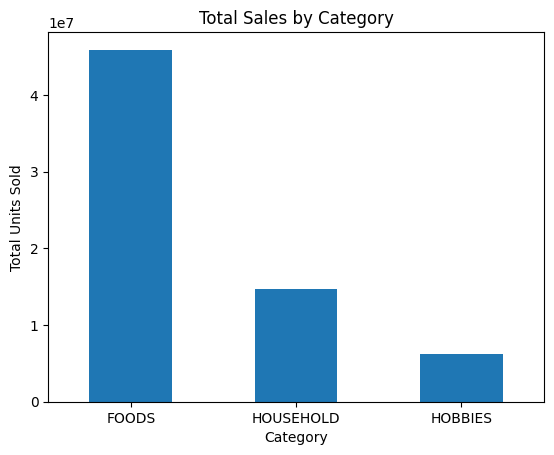

In [ ]:
import matplotlib.pyplot as plt

category_sales.plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=0)
plt.show()

**Finding:**

Sales were analyzed across the three major categories: FOODS, HOBBIES, and HOUSEHOLD.
The category-level comparison helps identify which product category contributes the most to overall demand.
Category information can be used as an important feature in the forecasting model.

In [ ]:
store_sales = (
    sales.groupby('store_id')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

display(store_sales)

,total_sales
store_id,
CA_3,11363540
CA_1,7832248
TX_2,7329642
WI_2,6697988
WI_3,6542557
TX_3,6205940
CA_2,5818395
TX_1,5692823
WI_1,5261506


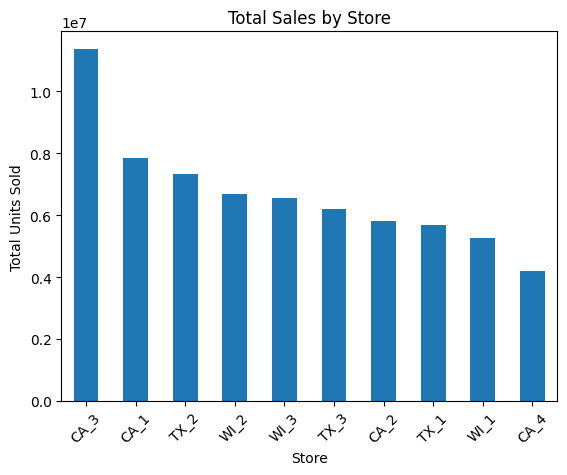

In [ ]:
store_sales.plot(kind='bar')

plt.title('Total Sales by Store')
plt.xlabel('Store')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)
plt.show()

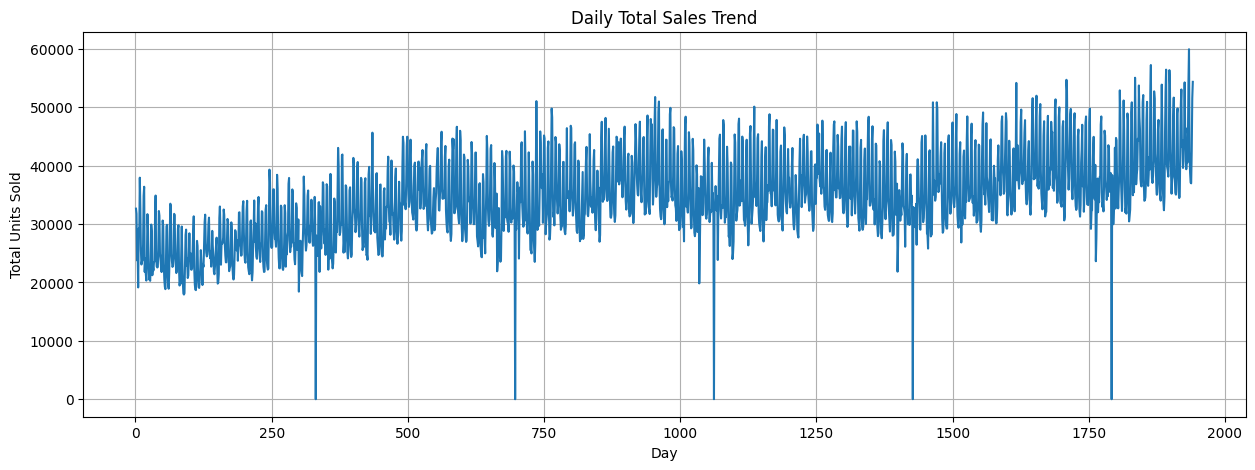

In [ ]:
daily_sales = sales[sales_columns].sum(axis=0)

daily_sales.index = range(1, len(daily_sales) + 1)

plt.figure(figsize=(15, 5))
plt.plot(daily_sales)

plt.title('Daily Total Sales Trend')
plt.xlabel('Day')
plt.ylabel('Total Units Sold')
plt.grid(True)
plt.show()

In [3]:
import os

os.listdir()

['.config',
 'sales_train_evaluation (1).csv',
 'sell_prices (1).csv',
 'calendarfile.xlsx',
 'sample_data']

In [5]:
import os

print(os.getcwd())
print(os.listdir('/content'))

/content
['.config', 'sales_train_evaluation (1).csv', 'sell_prices (1).csv', 'calendarfile.xlsx', 'sample_data']


In [10]:
import os

print(os.listdir('/content'))

['.config', 'sales_train_evaluation (1).csv', 'sell_prices (1).csv', 'calendarfile.xlsx', 'sample_data']


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

sales_df = pd.read_csv('/content/sales_train_evaluation (1).csv')

print(sales_df.shape)
sales_df.head()

(30490, 1947)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [13]:
days = [col for col in sales_df.columns if col.startswith('d_')]

print("Number of daily columns:", len(days))
print(days[:5])

Number of daily columns: 1941
['d_1', 'd_2', 'd_3', 'd_4', 'd_5']


In [14]:
daily_sales = sales_df[days].sum()

daily_sales.index = range(1, len(daily_sales) + 1)

print(daily_sales.head())

1    32631
2    31749
3    23783
4    25412
5    19146
dtype: int64


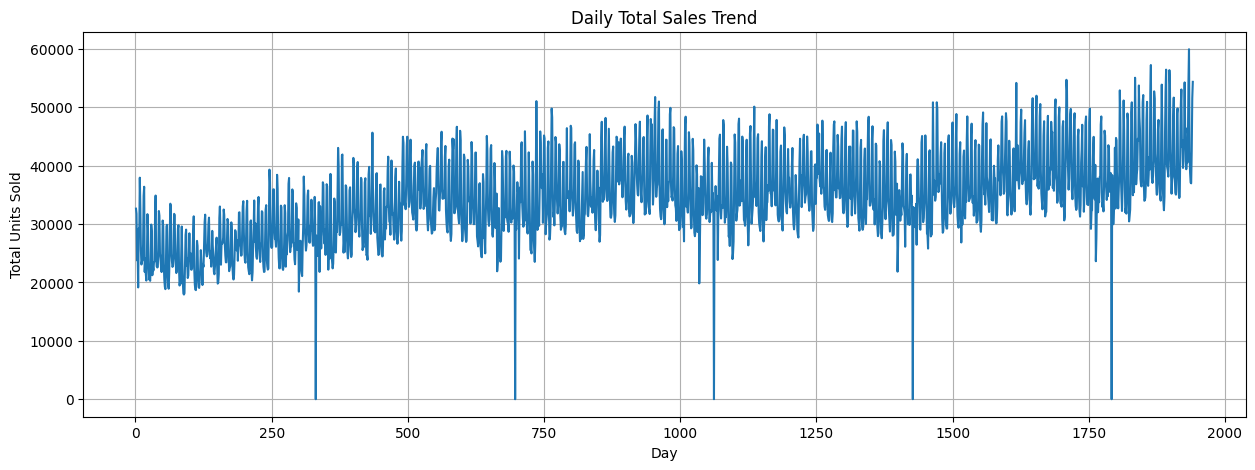

In [15]:
plt.figure(figsize=(15, 5))

plt.plot(daily_sales)

plt.title('Daily Total Sales Trend')

plt.xlabel('Day')

plt.ylabel('Total Units Sold')

plt.grid(True)

plt.show()

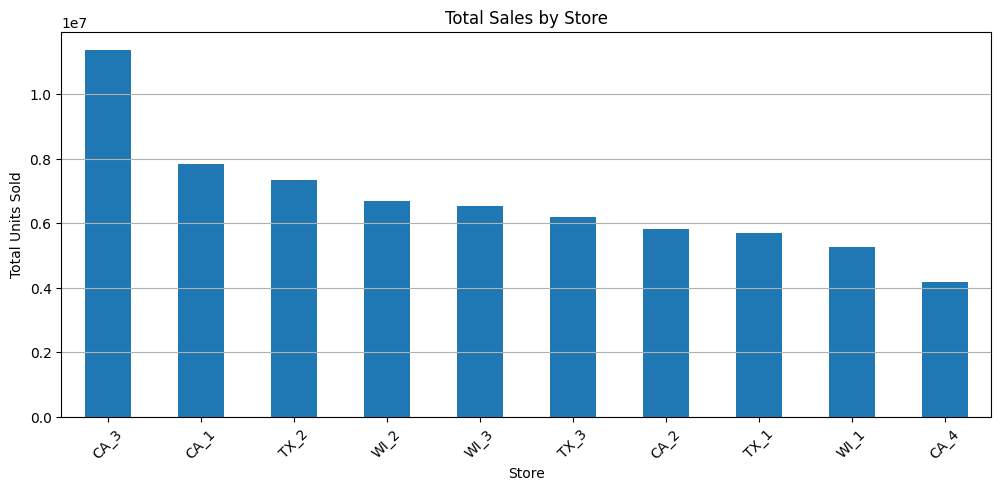

In [16]:
#Total sales by store

store_sales = sales_df.groupby('store_id')[days].sum().sum(axis=1)

store_sales = store_sales.sort_values(ascending=False)

plt.figure(figsize=(12, 5))

store_sales.plot(kind='bar')

plt.title('Total Sales by Store')
plt.xlabel('Store')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)

plt.grid(axis='y')
plt.show()

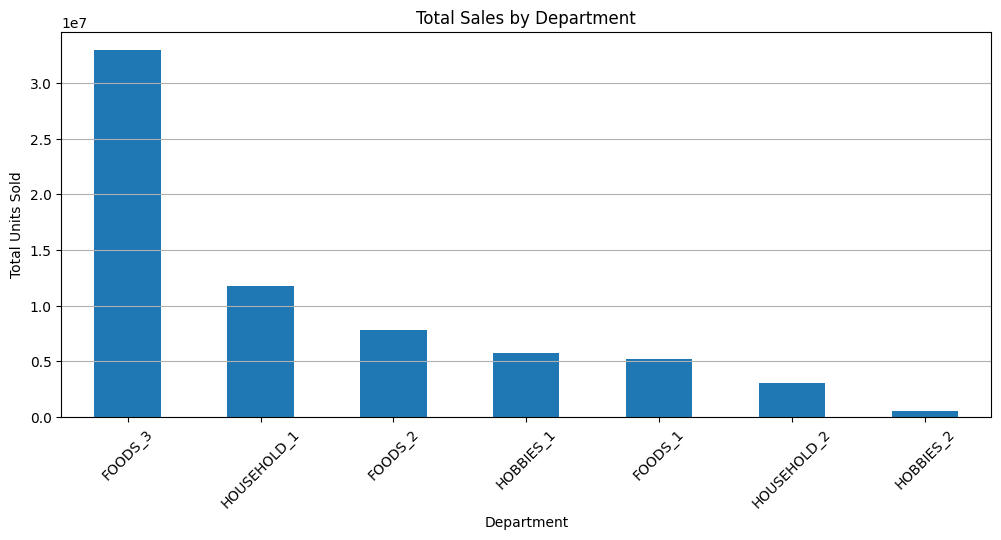

In [17]:
#Sales by Department
dept_sales = sales_df.groupby('dept_id')[days].sum().sum(axis=1)

dept_sales = dept_sales.sort_values(ascending=False)

plt.figure(figsize=(12, 5))

dept_sales.plot(kind='bar')

plt.title('Total Sales by Department')
plt.xlabel('Department')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)

plt.grid(axis='y')
plt.show()

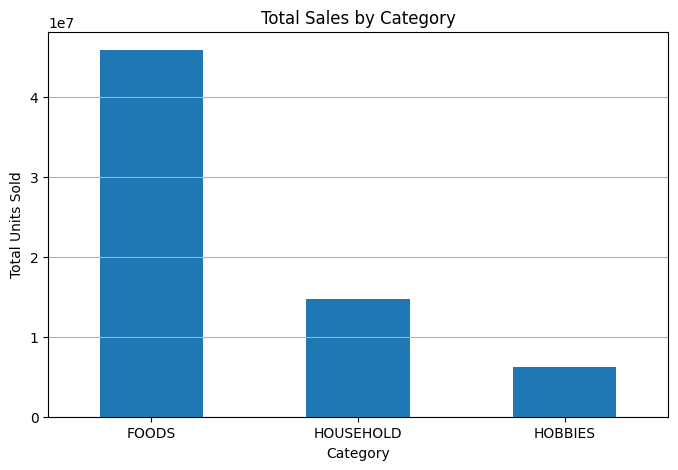

In [18]:
#Sales by Category
category_sales = sales_df.groupby('cat_id')[days].sum().sum(axis=1)

category_sales = category_sales.sort_values(ascending=False)

plt.figure(figsize=(8, 5))

category_sales.plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=0)

plt.grid(axis='y')
plt.show()

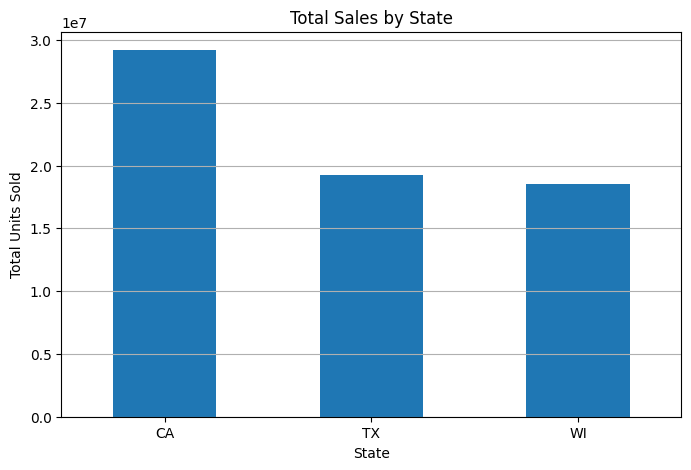

In [19]:
#Sales by State

state_sales = sales_df.groupby('state_id')[days].sum().sum(axis=1)

state_sales = state_sales.sort_values(ascending=False)

plt.figure(figsize=(8, 5))

state_sales.plot(kind='bar')

plt.title('Total Sales by State')
plt.xlabel('State')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=0)

plt.grid(axis='y')
plt.show()

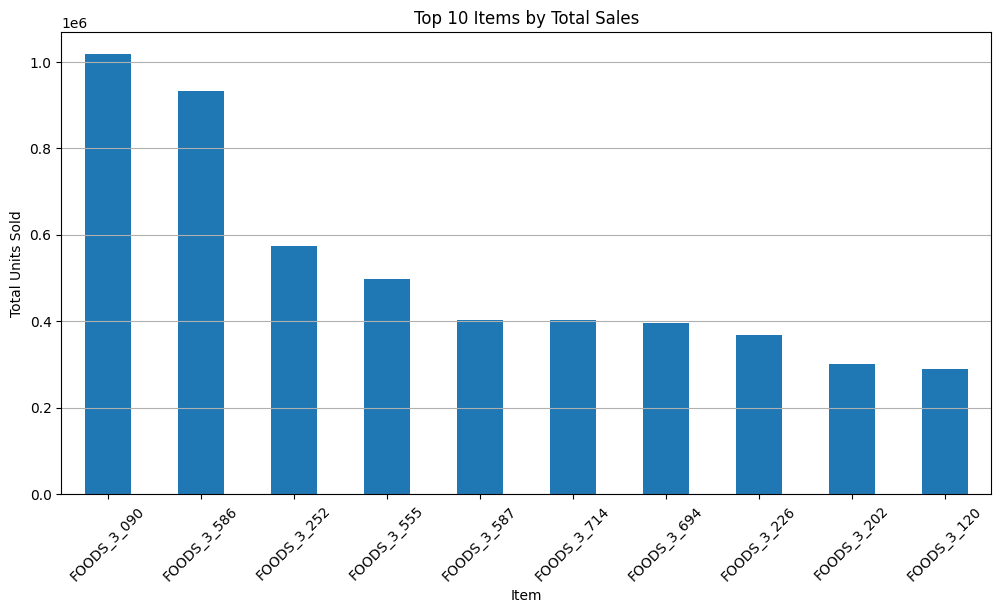

In [20]:
#Top 10 Items by Sales

item_sales = sales_df.groupby('item_id')[days].sum().sum(axis=1)

top_10_items = item_sales.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))

top_10_items.plot(kind='bar')

plt.title('Top 10 Items by Total Sales')
plt.xlabel('Item')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)

plt.grid(axis='y')
plt.show()

In [21]:
#Analyze sales by day of week

calendar_df = pd.read_excel('/content/calendarfile.xlsx')

print(calendar_df.shape)
calendar_df.head()

(1969, 14)


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [22]:
#Average Sales by Day of Week
# Create a dataframe combining daily sales and calendar information

daily_sales_df = pd.DataFrame({
    'd': [f'd_{i}' for i in range(1, len(daily_sales) + 1)],
    'sales': daily_sales.values
})

daily_sales_df = daily_sales_df.merge(
    calendar_df[['d', 'weekday']],
    on='d',
    how='left'
)

daily_sales_df.head()

,d,sales,weekday
0,d_1,32631,Saturday
1,d_2,31749,Sunday
2,d_3,23783,Monday
3,d_4,25412,Tuesday
4,d_5,19146,Wednesday


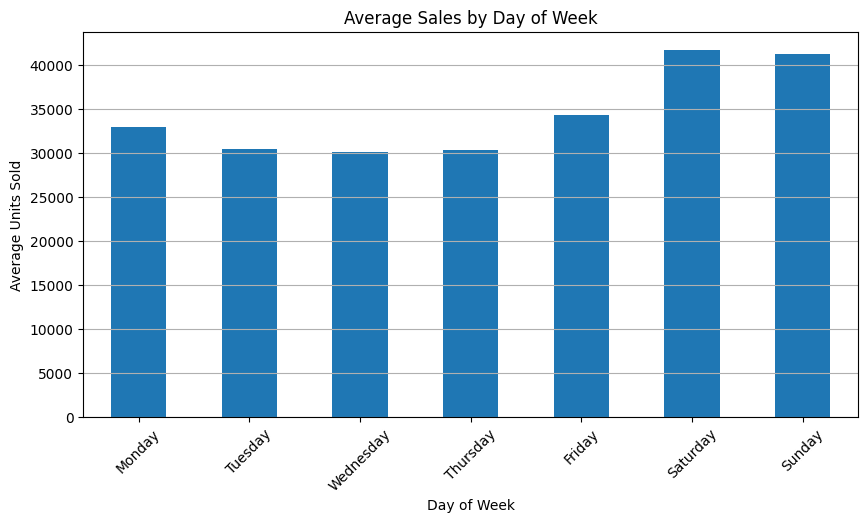

In [23]:
weekday_sales = daily_sales_df.groupby('weekday')['sales'].mean()

weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

weekday_sales = weekday_sales.reindex(weekday_order)

plt.figure(figsize=(10, 5))

weekday_sales.plot(kind='bar')

plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Units Sold')
plt.xticks(rotation=45)

plt.grid(axis='y')
plt.show()

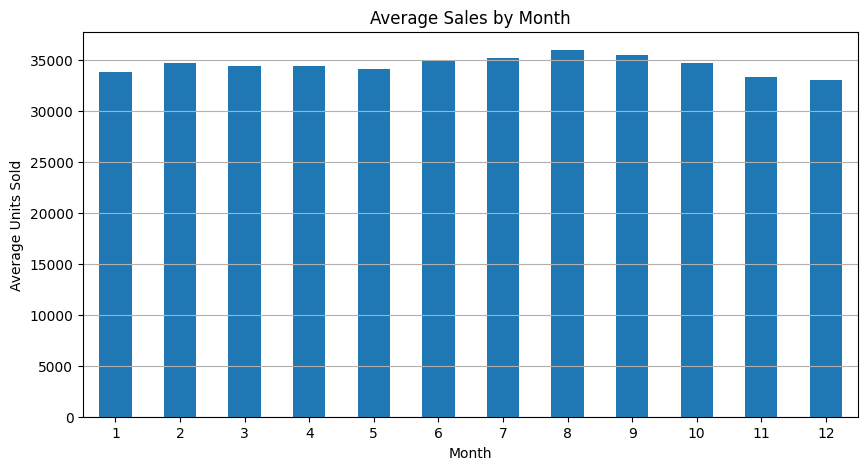

In [24]:
#Monthly Sales Trend

daily_sales_df['month'] = daily_sales_df['d'].map(
    calendar_df.set_index('d')['month']
)

monthly_sales = daily_sales_df.groupby('month')['sales'].mean()

plt.figure(figsize=(10, 5))

monthly_sales.plot(kind='bar')

plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Units Sold')
plt.xticks(rotation=0)

plt.grid(axis='y')
plt.show()

In [25]:
#Event/Holiday Impact
daily_sales_df = daily_sales_df.merge(
    calendar_df[['d', 'event_name_1']],
    on='d',
    how='left',
    suffixes=('', '_calendar')
)

daily_sales_df['event_day'] = daily_sales_df['event_name_1'].notna()

event_sales = daily_sales_df.groupby('event_day')['sales'].mean()

print(event_sales)

event_day
False    34609.336511
True     33029.911392
Name: sales, dtype: float64


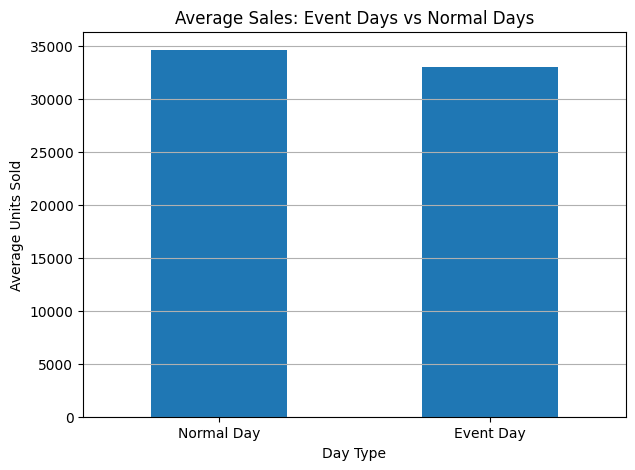

In [26]:
plt.figure(figsize=(7, 5))

event_sales.plot(kind='bar')

plt.title('Average Sales: Event Days vs Normal Days')
plt.xlabel('Day Type')
plt.ylabel('Average Units Sold')
plt.xticks(
    ticks=[0, 1],
    labels=['Normal Day', 'Event Day'],
    rotation=0
)

plt.grid(axis='y')
plt.show()

| Analysis                   | Finding                |
| -------------------------- | ---------------------- |
| Daily sales trend          | Trend analyzed         |
| Highest-selling store      | **CA_3**               |
| Highest-selling department | **FOODS**              |
| Highest-selling category   | **FOODS**              |
| Highest-selling state      | **CA**                 |
| Top-selling item           | **FOODS_3_090**        |
| Highest-sales weekday      | **Saturday**           |
| Highest-sales month        | **August (8)**         |
| Event vs normal days       | **Normal days higher** |
